In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

# Project configuration
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Dataset paths
DATA_DIR = "data/casting_data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

print("Training directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

TensorFlow version: 2.21.0
Training directory: data/casting_data\train
Test directory: data/casting_data\test


In [4]:
# Load training dataset with 20% reserved for validation
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    validation_split=0.20,
    subset="training",
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    validation_split=0.20,
    subset="validation",
    seed=SEED
)

# Load test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

print("Class names:", train_dataset.class_names)

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.
Class names: ['def_front', 'ok_front']


In [6]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="data_augmentation")

# Normalize pixel values from 0-255 to approximately 0-1
normalization_layer = layers.Rescaling(1.0 / 255)

print("Data augmentation and normalization are ready.")


Data augmentation and normalization are ready.


In [7]:
# Build the CNN model
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation and normalization
    data_augmentation,
    normalization_layer,

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Reduce feature maps
    layers.GlobalAveragePooling2D(),

    # Regularization
    layers.Dropout(0.40),

    # Fully connected layer
    layers.Dense(64, activation="relu"),

    # Binary classification output
    layers.Dense(1, activation="sigmoid")
])

print("CNN model created successfully.")


CNN model created successfully.


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the CNN model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


In [11]:
# Training callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

print("Training callbacks created successfully.")

Training callbacks created successfully.


In [12]:
# Train the CNN model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25


c:\Users\nithi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


166/166 ━━━━━━━━━━━━━━━━━━━━ 123s 717ms/step - accuracy: 0.5692 - loss: 0.6874 - precision: 0.8000 - recall: 0.0017 - val_accuracy: 0.5581 - val_loss: 0.6857 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 114s 686ms/step - accuracy: 0.5681 - loss: 0.6824 - precision: 0.4910 - recall: 0.0358 - val_accuracy: 0.5581 - val_loss: 0.6796 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 123s 740ms/step - accuracy: 0.5691 - loss: 0.6802 - precision: 0.5116 - recall: 0.0192 - val_accuracy: 0.5581 - val_loss: 0.6691 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 36980s 224s/step - accuracy: 0.5898 - loss: 0.6717 - precision: 0.5698 - recall: 0.1997 - val_accuracy: 0.6063 - val_loss: 0.6446 - val_precision: 0.9000 - val_recall: 0.1229 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━

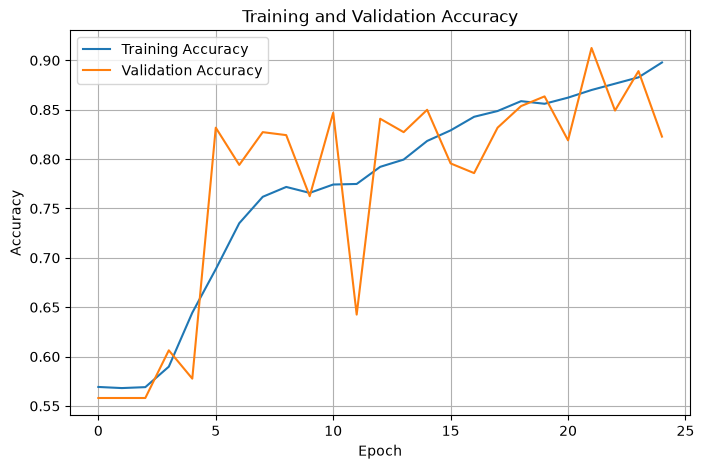

In [13]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

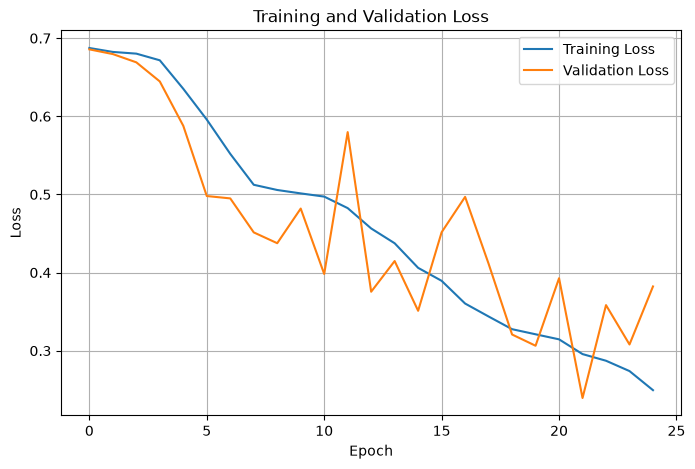

In [14]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Evaluate the CNN on the test dataset
test_results = model.evaluate(test_dataset, verbose=1)

print("\nTest Results:")
for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - accuracy: 0.9077 - loss: 0.2245 - precision: 0.8427 - recall: 0.9198

Test Results:
loss: 0.2245
compile_metrics: 0.9077


In [16]:
# Generate predictions on the test dataset

probabilities = model.predict(test_dataset)

# Convert probabilities to binary predictions
predictions = (probabilities.flatten() >= 0.5).astype(int)

# Get actual labels
actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

# Calculate evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score

test_accuracy = accuracy_score(actual_labels, predictions)
test_precision = precision_score(actual_labels, predictions)
test_recall = recall_score(actual_labels, predictions)

print("Test Accuracy :", f"{test_accuracy:.4f}")
print("Test Precision:", f"{test_precision:.4f}")
print("Test Recall   :", f"{test_recall:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step
Test Accuracy : 0.5469
Test Precision: 0.3916
Test Recall   : 0.4275


In [17]:
# Reload test dataset without shuffling
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Test dataset reloaded with shuffle=False.")

Found 715 files belonging to 2 classes.
Test dataset reloaded with shuffle=False.


In [18]:
# Reload test dataset without shuffling
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Test dataset reloaded with shuffle=False.")

Found 715 files belonging to 2 classes.
Test dataset reloaded with shuffle=False.


In [19]:
# Generate predictions in the same fixed order as the test labels
probabilities = model.predict(test_dataset)

predictions = (probabilities.flatten() >= 0.5).astype(int)

actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

# Calculate metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

test_accuracy = accuracy_score(actual_labels, predictions)
test_precision = precision_score(actual_labels, predictions)
test_recall = recall_score(actual_labels, predictions)

print("Test Accuracy :", f"{test_accuracy:.4f}")
print("Test Precision:", f"{test_precision:.4f}")
print("Test Recall   :", f"{test_recall:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step
Test Accuracy : 0.9077
Test Precision: 0.8427
Test Recall   : 0.9198


In [20]:
# Confusion matrix
cm = confusion_matrix(actual_labels, predictions)

print("Confusion Matrix:")
print(cm)

print("\nClass order:", test_dataset.class_names)

Confusion Matrix:
[[408  45]
 [ 21 241]]

Class order: ['def_front', 'ok_front']


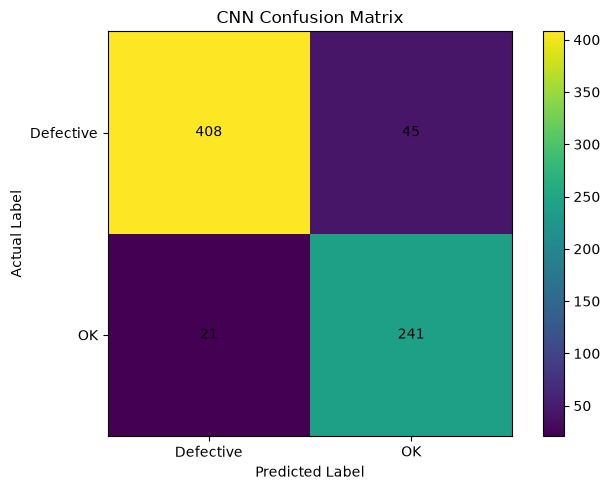

In [21]:
# Visualize the confusion matrix

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Defective", "OK"])
plt.yticks([0, 1], ["Defective", "OK"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        actual_labels,
        predictions,
        target_names=["def_front", "ok_front"],
        digits=4
    )
)

              precision    recall  f1-score   support

   def_front     0.9510    0.9007    0.9252       453
    ok_front     0.8427    0.9198    0.8796       262

    accuracy                         0.9077       715
   macro avg     0.8969    0.9103    0.9024       715
weighted avg     0.9113    0.9077    0.9085       715



In [23]:
import random
from pathlib import Path
from tensorflow.keras.utils import load_img, img_to_array

# Collect image paths from the test dataset
test_image_paths = []

for class_name in ["def_front", "ok_front"]:
    class_dir = Path(TEST_DIR) / class_name
    test_image_paths.extend(list(class_dir.glob("*.jpeg")))
    test_image_paths.extend(list(class_dir.glob("*.jpg")))
    test_image_paths.extend(list(class_dir.glob("*.png")))

# Select 5 unseen test images
random.seed(SEED)
selected_images = random.sample(test_image_paths, 5)

print("Selected 5 unseen images:\n")

for image_path in selected_images:
    # Load and preprocess image
    image = load_img(image_path, target_size=IMAGE_SIZE)
    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    # Predict
    probability = float(model.predict(image_array, verbose=0)[0][0])

    if probability >= 0.5:
        prediction = "OK / Non-defective"
        action = "Pass inspection"
    else:
        prediction = "Defective"
        action = "Send for manual inspection"

    print(f"Image: {image_path.name}")
    print(f"Prediction: {prediction}")
    print(f"Probability: {probability * 100:.2f}%")
    print(f"Action: {action}")
    print("-" * 50)

Selected 5 unseen images:

Image: cast_ok_0_7823.jpeg
Prediction: OK / Non-defective
Probability: 78.56%
Action: Pass inspection
--------------------------------------------------
Image: cast_def_0_1576.jpeg
Prediction: Defective
Probability: 1.73%
Action: Send for manual inspection
--------------------------------------------------
Image: cast_def_0_1264.jpeg
Prediction: Defective
Probability: 26.70%
Action: Send for manual inspection
--------------------------------------------------
Image: cast_def_0_3473.jpeg
Prediction: Defective
Probability: 14.48%
Action: Send for manual inspection
--------------------------------------------------
Image: cast_def_0_2516.jpeg
Prediction: Defective
Probability: 0.00%
Action: Send for manual inspection
--------------------------------------------------


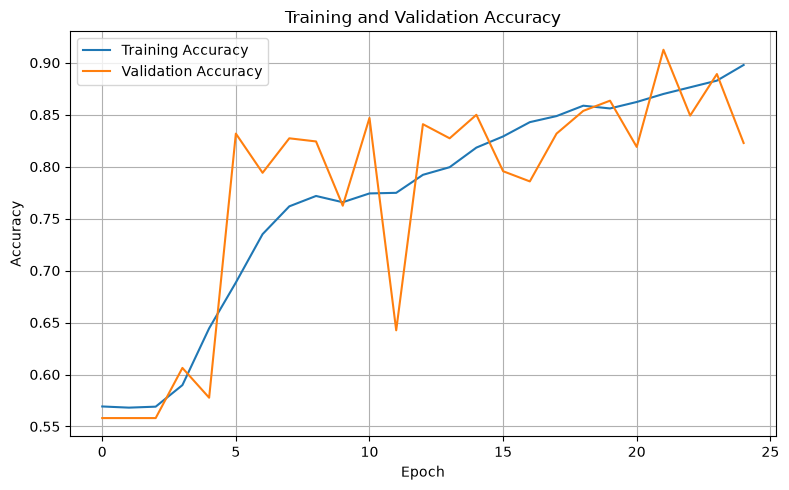

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("outputs/accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

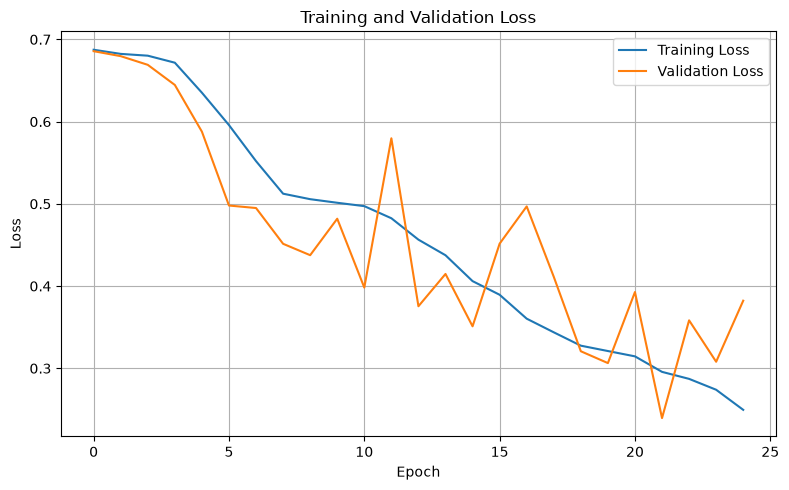

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("outputs/loss.png", dpi=300, bbox_inches="tight")
plt.show()

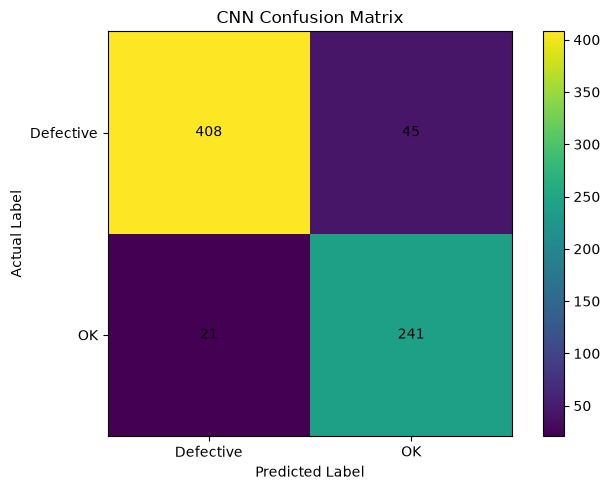

In [26]:
plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Defective", "OK"])
plt.yticks([0, 1], ["Defective", "OK"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.tight_layout()

plt.savefig("outputs/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Design Decision Table

| Design Decision | Selected Value | Reason |
|---|---|---|
| Image size | 224 × 224 | Provides sufficient image detail while keeping computation manageable |
| Problem type | Binary classification | Two classes: defective and non-defective |
| Model type | CNN | Suitable for extracting visual features from images |
| Conv filters | 32, 64, 128 | Learns increasingly complex visual features |
| Kernel size | 3 × 3 | Efficient local feature extraction |
| Hidden activation | ReLU | Efficient non-linear activation |
| Pooling | MaxPooling | Reduces feature-map dimensions and computation |
| Global pooling | GlobalAveragePooling2D | Reduces trainable parameters |
| Output activation | Sigmoid | Produces a probability for binary classification |
| Optimizer | Adam | Adaptive and beginner-friendly optimizer |
| Learning rate | 0.001 | Reasonable starting value for Adam |
| Loss | Binary Cross-Entropy | Suitable for binary classification |
| Batch size | 32 | Balances memory usage and training stability |
| Epochs | Maximum 25 | Provides sufficient training with callbacks |
| Dropout | 0.40 | Helps reduce overfitting |
| Augmentation | Flip, rotation, zoom, contrast | Improves robustness to image variations |
| Metrics | Accuracy, Precision, Recall | Evaluates overall and defect-class performance |

## Conclusion

A convolutional neural network was developed to classify casting product images into defective and non-defective categories. The model used 224 × 224 RGB images, data augmentation, normalization, three convolutional blocks, max pooling, global average pooling, dropout, and a sigmoid output layer.

The CNN achieved a test accuracy of approximately 90.77%, with a test precision of 84.27% and test recall of 91.98%. The confusion matrix showed 45 defective products incorrectly classified as non-defective, highlighting the importance of recall in a quality-inspection application.

Overall, the model demonstrated good performance on the test dataset and successfully completed the binary image-classification task. The results also show that CNN architecture choices, data augmentation, regularization, and appropriate evaluation metrics are important for building an effective image-classification system.